<a href="https://colab.research.google.com/github/ajaynice1996/DIY_MRI_Workshop_II_Recon/blob/main/Day_3_Notebook_1_1_SRR_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Super-Resolution Reconstruction Basics


Include 3D discussion in this as well;

    MRI spatial resolution
            ↓
    HR and LR images
            ↓
    Create LR by degradation
            ↓
    Upsampling / interpolation
            ↓
    Why interpolation ≠ SR
            ↓
    Patch extraction
            ↓
    Data augmentation
            ↓
    CNN for SR
            ↓
    Loss function
            ↓
    Optimization
            ↓
    Supervised SR training
            ↓
    Evaluation
            ↓
    Limitations of supervised SR
            ↓
    Motivation for ZSSR

  # Day 3 — Notebook 1.1
  # Super-Resolution Reconstruction (SRR) Basics

  ## Learning objectives

  By the end of this notebook, you will be able to:

      1. Explain MRI spatial resolution.
      2. Distinguish high-resolution (HR) and low-resolution (LR) images.
      3. Understand image degradation and downsampling.
      4. Explain why interpolation is not the same as super-resolution.
      5. Extract corresponding LR/HR image patches.
      6. Apply paired data augmentation.
      7. Build a small CNN for SR.
      8. Define SR reconstruction losses.
      9. Understand backpropagation and optimization.
      10. Train a simple supervised SR model.
      11. Evaluate SR using PSNR and SSIM.
      12. Understand the limitations of supervised SR.

  ### Important

  The next notebook will use the concepts developed here to answer:

  > What can we do when we have only one LR image and no external HR target?

# Module 0 — Setup

    We will first import the libraries needed for:

    - MRI/image handling
    - visualization
    - numerical operations
    - PyTorch
    - image metrics

    We will initially work with a 2-D slice because it makes the SR concepts easier to understand.

    The same concepts can later be extended to 3-D MRI volumes.

In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


# Module 1 — MRI Image and Spatial Resolution

    Before discussing super-resolution, we need to understand what
    "resolution" means in MRI.

    An MRI image has:

    - matrix dimensions
    - voxel dimensions
    - field of view (FOV)

    For example:

        Matrix:       224 × 224
        Voxel size:   1 × 1 mm

    The matrix tells us how many pixels are present.

    The voxel size tells us the physical size represented by each pixel.

### Important

    Increasing the matrix size does not automatically mean that the image
    contains more true spatial information.

In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch

# Workshop root directory
workshop_dir = "/drive/MyDrive/1DIY_MRI_Recon/data/"

# Select image
image_path = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T2.nii.gz"
)

print("Loading:", image_path)

# Load NIfTI
nii = nib.load(image_path)

# Convert to NumPy array
volume = nii.get_fdata().astype(np.float32)

# Basic information
print("\nMRI information")
print("----------------")
print("Shape:", volume.shape)
print("Voxel spacing:", nii.header.get_zooms()[:3])
print("Data type:", volume.dtype)
print("Minimum intensity:", volume.min())
print("Maximum intensity:", volume.max())
print("Mean intensity:", volume.mean())
print("Standard deviation:", volume.std())

Loading: /drive/MyDrive/1DIY_MRI_Recon/data/3T/POCEMR001_T2.nii.gz

MRI information
----------------
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 38.78939
Standard deviation: 53.17793


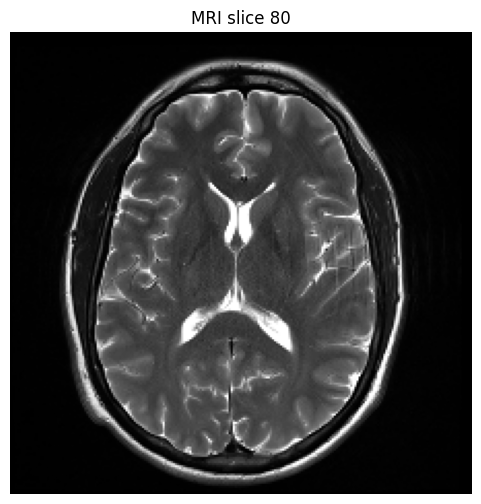

In [ ]:
# Select the middle slice
slice_idx = volume.shape[2] // 2
hr = volume[:, :, slice_idx]

plt.figure(figsize=(6, 6))
plt.imshow(hr.T, cmap="gray", origin='lower')
plt.title(f"MRI slice {slice_idx}")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

def normalize_image(image):
    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    if max_val == min_val:
        return np.zeros_like(image)

    image_norm = (image - min_val) / (max_val - min_val)

    return image_norm

In [ ]:
# Original MRI slice
hr_original = hr.astype(np.float32)

# Normalize HR
hr = normalize_image(hr_original)

print("Original HR:")
print("Min:", hr_original.min())
print("Max:", hr_original.max())

print("\nNormalized HR:")
print("Min:", hr.min())
print("Max:", hr.max())

Original HR:
Min: 0.0
Max: 255.0

Normalized HR:
Min: 0.0
Max: 1.0


# Module 2 — High Resolution and Low Resolution

We will use:

    HR = High Resolution
    LR = Low Resolution

Suppose our HR image is:

    224 × 224

If we reduce the spatial sampling by a factor of 2:

    224 × 224
          ↓
    112 × 112

we obtain an LR representation.

Conceptually:

              HR
               │
               │ degradation
               ↓
              LR

The SR problem reverses this direction:

              LR
               │
               │ SR reconstruction
               ↓
              HR-like image

# Module 3 — Creating a Low-Resolution Image

  A simplified degradation model is:

      LR = D(HR)

  where D is the degradation operator.

  For this notebook, D will include downsampling.

  Real MRI degradation can be more complicated and may involve:

  - acquisition resolution
  - point-spread function
  - blur
  - noise
  - reconstruction effects
  - scanner-specific characteristics
  - anisotropic sampling

  We begin with simple controlled degradation so that the SR problem
  is easy to understand.

In [ ]:
scale = 2

lr = resize(
    hr,
    (
        hr.shape[0] // scale,
        hr.shape[1] // scale
    ),
    order=3,
    preserve_range=True,
    anti_aliasing=True
).astype(np.float32)

print("HR shape:", hr.shape)
print("LR shape:", lr.shape)

HR shape: (224, 224)
LR shape: (112, 112)


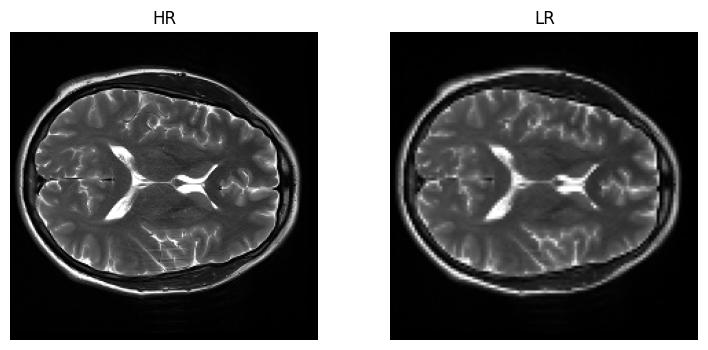

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

ax[0].imshow(
    hr,
    cmap="gray",

)
ax[0].set_title("HR")

ax[1].imshow(
    lr,
    cmap="gray",

)
ax[1].set_title("LR")

for a in ax:
    a.axis("off")

plt.show()

# Module 4 — Upsampling

Our LR image is:

    112 × 112

We can resize it back to:

    224 × 224

using interpolation.

We will compare:

1. Nearest-neighbor
2. Bilinear
3. Bicubic

These operations increase the number of pixels.

But:

> Upsampling does not automatically recover information that was lost
> during degradation.

In [ ]:
nearest = resize(
    lr,
    hr.shape,
    order=0,
    preserve_range=True,
    anti_aliasing=False
)

bilinear = resize(
    lr,
    hr.shape,
    order=1,
    preserve_range=True,
    anti_aliasing=False
)

bicubic = resize(
    lr,
    hr.shape,
    order=3,
    preserve_range=True,
    anti_aliasing=False
)

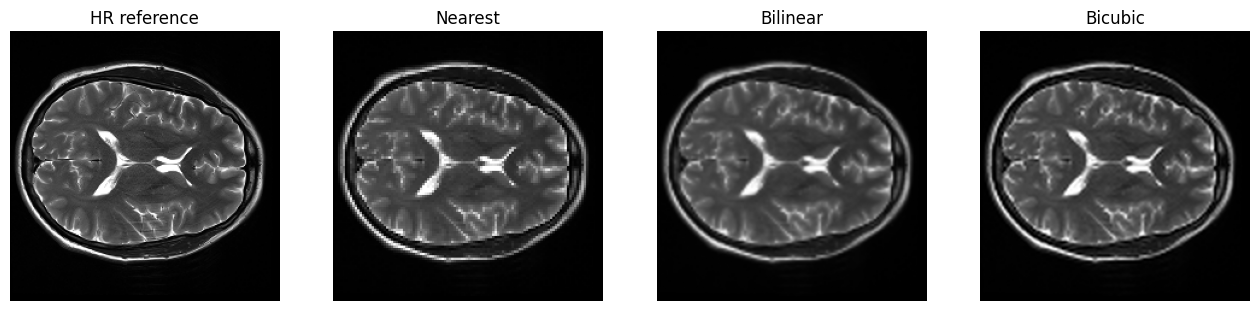

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

images = [
    hr,
    nearest,
    bilinear,
    bicubic
]

titles = [
    "HR reference",
    "Nearest",
    "Bilinear",
    "Bicubic"
]

for a, image, title in zip(ax, images, titles):

    a.imshow(
        image,
        cmap="gray",

    )

    a.set_title(title)
    a.axis("off")

plt.show()

# Module 5 — Measuring Reconstruction Quality

    Because we know the original HR image in this experiment,
    we can compare our reconstruction against it.

    We will use:

    - MSE
    - MAE
    - PSNR
    - SSIM

    ### Important

    These metrics require a reference image.

    Later, when we discuss ZSSR and real low-field MRI,
    the availability of a trustworthy HR reference becomes an important issue.

In [ ]:
def mse(reference, prediction):
    return np.mean(
        (reference - prediction) ** 2
    )


def mae(reference, prediction):
    return np.mean(
        np.abs(reference - prediction)
    )


def psnr(
    reference,
    prediction,
    data_range=1.0
):

    error = mse(
        reference,
        prediction
    )

    if error == 0:
        return float("inf")

    return 10 * np.log10(
        (data_range ** 2) / error
    )

In [ ]:
for name, prediction in [
    ("Nearest", nearest),
    ("Bilinear", bilinear),
    ("Bicubic", bicubic)
]:

    print(
        f"{name:8s} | "
        f"MSE: {mse(hr, prediction):.6f} | "
        f"MAE: {mae(hr, prediction):.6f} | "
        f"PSNR: {psnr(hr, prediction):.2f} dB | "
        f"SSIM: {ssim(hr, prediction, data_range=1.0):.4f}"
    )

Nearest  | MSE: 0.003890 | MAE: 0.026579 | PSNR: 24.10 dB | SSIM: 0.8944
Bilinear | MSE: 0.003507 | MAE: 0.026787 | PSNR: 24.55 dB | SSIM: 0.8886
Bicubic  | MSE: 0.002630 | MAE: 0.023606 | PSNR: 25.80 dB | SSIM: 0.9104


In [ ]:
print("Min/Max of each image:")
print("-----------------------")

for name, image in [
    ("LR", lr),
    ("Nearest", nearest),
    ("Bilinear", bilinear),
    ("Bicubic", bicubic),
    ("HR reference", hr)
]:
    print(f"{name:12s} | Min: {image.min():.4f}, Max: {image.max():.4f}")

Min/Max of each image:
-----------------------
LR           | Min: 0.0000, Max: 1.0000
Nearest      | Min: 0.0000, Max: 1.0000
Bilinear     | Min: 0.0000, Max: 0.9999
Bicubic      | Min: 0.0000, Max: 1.0000
HR reference | Min: 0.0000, Max: 1.0000


# Module 6 — From Interpolation to Learned SR

Interpolation uses a fixed mathematical rule.

A neural network instead tries to learn a mapping:

    SR = fθ(LR)

where:

- LR = low-resolution input
- SR = predicted high-resolution image
- fθ = neural network
- θ = learnable parameters

The network is trained using an HR target:

                HR target
                    ↑
                    │
    LR → CNN → SR → Loss
                    │
                    ↓
               optimization

The objective is:

    θ* = argminθ L(fθ(LR), HR)

# Some Intermediate training strategies

# Module 7 — Patch Extraction

Large images are often divided into smaller patches.

Why?

- Lower memory requirement
- More training samples
- Easier augmentation
- Learning local image structures

For a scale factor of 2:

    HR patch = 32 × 32
    LR patch = 16 × 16

The LR and HR patches must correspond to the same anatomical region.

This is called an aligned LR-HR pair.

In [ ]:
def extract_aligned_patches(
    lr,
    hr,
    patch_hr=32,
    scale=2,
    stride=16
):

    patch_lr = patch_hr // scale

    lr_patches = []
    hr_patches = []

    for r_hr in range(
        0,
        hr.shape[0] - patch_hr + 1,
        stride
    ):

        for c_hr in range(
            0,
            hr.shape[1] - patch_hr + 1,
            stride
        ):

            r_lr = r_hr // scale
            c_lr = c_hr // scale

            hr_patch = hr[
                r_hr:r_hr + patch_hr,
                c_hr:c_hr + patch_hr
            ]

            lr_patch = lr[
                r_lr:r_lr + patch_lr,
                c_lr:c_lr + patch_lr
            ]

            lr_patches.append(lr_patch)
            hr_patches.append(hr_patch)

    return (
        np.stack(lr_patches),
        np.stack(hr_patches)
    )

In [ ]:
lr_patches, hr_patches = extract_aligned_patches(
    lr,
    hr,
    patch_hr=32,
    scale=2,
    stride=16
)

print("Number of patches:", len(lr_patches))
print("LR patches:", lr_patches.shape)
print("HR patches:", hr_patches.shape)

Number of patches: 169
LR patches: (169, 16, 16)
HR patches: (169, 32, 32)


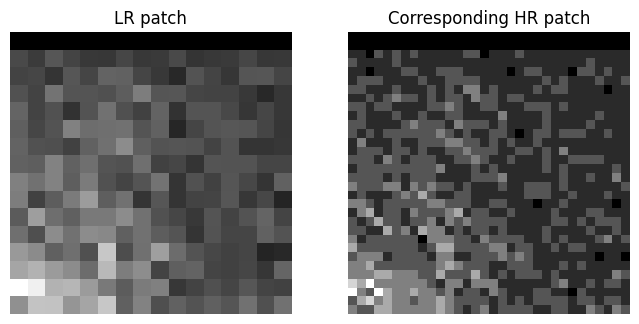

In [ ]:
patch_id = 10

fig, ax = plt.subplots(
    1, 2,
    figsize=(8, 4)
)

ax[0].imshow(
    lr_patches[patch_id],
    cmap="gray"

)

ax[0].set_title("LR patch")

ax[1].imshow(
    hr_patches[patch_id],
    cmap="gray"

)

ax[1].set_title("Corresponding HR patch")

for a in ax:
    a.axis("off")

plt.show()

## Student Exercise — Change the Patch Size

Try:

    patch_hr = 48

instead of:

    patch_hr = 32

Then answer:

1. How many patches are generated?
2. What is the corresponding LR patch size?
3. What happens to the number of training examples?
4. What happens if the stride is reduced?

Try:

    stride = 8


# Module 9 — Data Augmentation

  We can create additional training examples using transformations.

  Examples:

  - horizontal flip
  - vertical flip
  - rotation

  ### Critical rule

  The same spatial transformation must be applied to both LR and HR.

  Correct:

      LR → rotate
      HR → rotate

  Incorrect:

      LR → rotate
      HR → unchanged

In [ ]:
def augment_pair(
    lr_patch,
    hr_patch,
    mode=0
):

    if mode == 0:
        return lr_patch, hr_patch

    if mode == 1:
        return (
            np.flip(lr_patch, axis=0).copy(),
            np.flip(hr_patch, axis=0).copy()
        )

    if mode == 2:
        return (
            np.flip(lr_patch, axis=1).copy(),
            np.flip(hr_patch, axis=1).copy()
        )

    if mode == 3:
        return (
            np.rot90(lr_patch).copy(),
            np.rot90(hr_patch).copy()
        )

    raise ValueError(
        "mode must be 0, 1, 2, or 3"
    )

# Module 10 — A Small CNN for SR

We will begin with a deliberately small network.

The idea is:

    LR
     ↓
    Conv
     ↓
    ReLU
     ↓
    Conv
     ↓
    ReLU
     ↓
    Conv
     ↓
    SR

We will first use bicubic interpolation to change the spatial size.

Therefore:

    LR
     ↓
    Bicubic ×2
     ↓
    CNN
     ↓
    SR

This keeps the first CNN exercise simple.

Later, learned upsampling methods such as PixelShuffle can be introduced.

In [ ]:
class SmallSRNet(nn.Module):

    def __init__(
        self,
        channels=32
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            channels,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            channels,
            1,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(self, x):

        x = F.interpolate(
            x,
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        x = self.relu(
            self.conv1(x)
        )

        x = self.relu(
            self.conv2(x)
        )

        x = self.conv3(x)

        return x

# Student Exercise — Build Your Own SR CNN

Complete the missing parts.

```python
class MySRNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = ______________________

        self.conv2 = ______________________

        self.conv3 = ______________________

    def forward(self, x):

        x = ______________________

        x = ______________________

        x = ______________________

        x = ______________________

        x = ______________________

        return x


---

# Module 12 — PyTorch dataset

## Cell 28 — Markdown

```markdown
# Module 12 — Preparing the Training Dataset

Our supervised SR dataset consists of:

    LR patch ↔ HR patch

The network receives the LR patch.

The HR patch is the target.

In [ ]:
class SRPatchDataset(Dataset):

    def __init__(
        self,
        lr_patches,
        hr_patches
    ):

        self.lr = lr_patches.astype(
            np.float32
        )

        self.hr = hr_patches.astype(
            np.float32
        )

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, idx):

        lr = torch.from_numpy(
            self.lr[idx]
        ).unsqueeze(0)

        hr = torch.from_numpy(
            self.hr[idx]
        ).unsqueeze(0)

        return lr, hr

In [ ]:
dataset = SRPatchDataset(
    lr_patches,
    hr_patches
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

lr_batch, hr_batch = next(
    iter(loader)
)

print("LR batch:", lr_batch.shape)
print("HR batch:", hr_batch.shape)

LR batch: torch.Size([8, 1, 16, 16])
HR batch: torch.Size([8, 1, 32, 32])


# Module 13 — Reconstruction Loss

The network produces:

    SR prediction

We compare it with:

    HR target

A simple loss is MSE:

        1
L = ------- Σ (SR - HR)²
        N

Another common loss is MAE/L1:

        1
L = ------- Σ |SR - HR|
        N

In [ ]:
def mse_loss(
    prediction,
    target
):

    return torch.mean(
        (prediction - target) ** 2
    )


def mae_loss(
    prediction,
    target
):

    return torch.mean(
        torch.abs(
            prediction - target
        )
    )


---

# Module 14 — Optimization

## Cell 34 — Markdown

```markdown
# Module 14 — Optimization

Training follows this cycle:

    LR
     ↓
    CNN
     ↓
    SR prediction
     ↓
    Loss(SR, HR)
     ↓
    Backpropagation
     ↓
    Optimizer
     ↓
    Update network parameters
     ↓
    Repeat

The optimizer changes the CNN parameters so that
the reconstruction loss decreases.

In [ ]:
model = SmallSRNet().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)
print(optimizer)

SmallSRNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU(inplace=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Module 15 — Training loop

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    for lr_batch, hr_batch in loader:

        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        optimizer.zero_grad()

        prediction = model(
            lr_batch
        )

        loss = criterion(
            prediction,
            hr_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return (
        running_loss / len(loader)
    )

In [ ]:
model = SmallSRNet().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

loss_history = []

num_epochs = 100

for epoch in range(num_epochs):

    loss = train_one_epoch(
        model,
        loader,
        optimizer,
        criterion,
        device
    )

    loss_history.append(loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss = {loss:.6f}"
    )

Epoch 01 | Loss = 0.022055
Epoch 02 | Loss = 0.008061
Epoch 03 | Loss = 0.005445
Epoch 04 | Loss = 0.003932
Epoch 05 | Loss = 0.003633
Epoch 06 | Loss = 0.003427
Epoch 07 | Loss = 0.003118
Epoch 08 | Loss = 0.003196
Epoch 09 | Loss = 0.002928
Epoch 10 | Loss = 0.002899
Epoch 11 | Loss = 0.002915
Epoch 12 | Loss = 0.002770
Epoch 13 | Loss = 0.002757
Epoch 14 | Loss = 0.002818
Epoch 15 | Loss = 0.002700
Epoch 16 | Loss = 0.002936
Epoch 17 | Loss = 0.002721
Epoch 18 | Loss = 0.002802
Epoch 19 | Loss = 0.002791
Epoch 20 | Loss = 0.002799
Epoch 21 | Loss = 0.002737
Epoch 22 | Loss = 0.002765
Epoch 23 | Loss = 0.002673
Epoch 24 | Loss = 0.002676
Epoch 25 | Loss = 0.002722
Epoch 26 | Loss = 0.002731
Epoch 27 | Loss = 0.002756
Epoch 28 | Loss = 0.002628
Epoch 29 | Loss = 0.002588
Epoch 30 | Loss = 0.002524
Epoch 31 | Loss = 0.002670
Epoch 32 | Loss = 0.002710
Epoch 33 | Loss = 0.002535
Epoch 34 | Loss = 0.002644
Epoch 35 | Loss = 0.002594
Epoch 36 | Loss = 0.002566
Epoch 37 | Loss = 0.002586
E

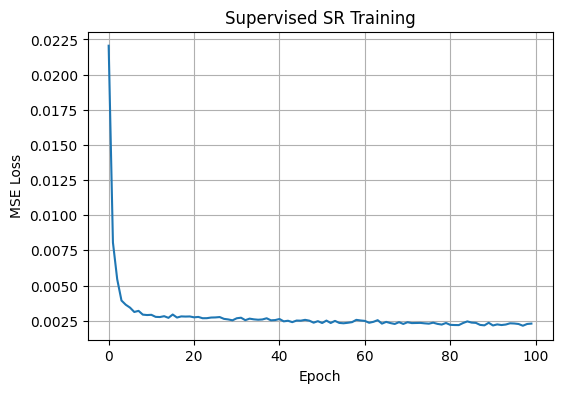

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Supervised SR Training")

plt.grid(True)

plt.show()

# Module 17 — Reconstruction

The network has now learned from LR-HR patch pairs.

We can provide the LR image to the trained network:

    LR
     ↓
    trained CNN
     ↓
    SR

In [ ]:


model.eval()

lr_tensor = torch.from_numpy(
    lr
).float().unsqueeze(0).unsqueeze(0)

lr_tensor = lr_tensor.to(device)

with torch.no_grad():

    sr_prediction = model(
        lr_tensor
    )

sr_prediction = (
    sr_prediction
    .squeeze()
    .cpu()
    .numpy()
)

sr_prediction = np.clip(
    sr_prediction,
    0,
    1
)

print("LR:", lr.shape)
print("SR:", sr_prediction.shape)
print("HR:", hr.shape)

LR: (112, 112)
SR: (224, 224)
HR: (224, 224)


In [ ]:
print("Min/Max of each image:")
print("-----------------------")

for name, image in [
    ("LR", lr),
    ("Bicubic", bicubic),
    ("CNN SR", sr_prediction),
    ("HR reference", hr)
]:
    print(f"{name:12s} | Min: {image.min():.4f}, Max: {image.max():.4f}")

Min/Max of each image:
-----------------------
LR           | Min: 0.0000, Max: 1.0000
Bicubic      | Min: 0.0000, Max: 1.0000
CNN SR       | Min: 0.0000, Max: 1.0000
HR reference | Min: 0.0000, Max: 1.0000


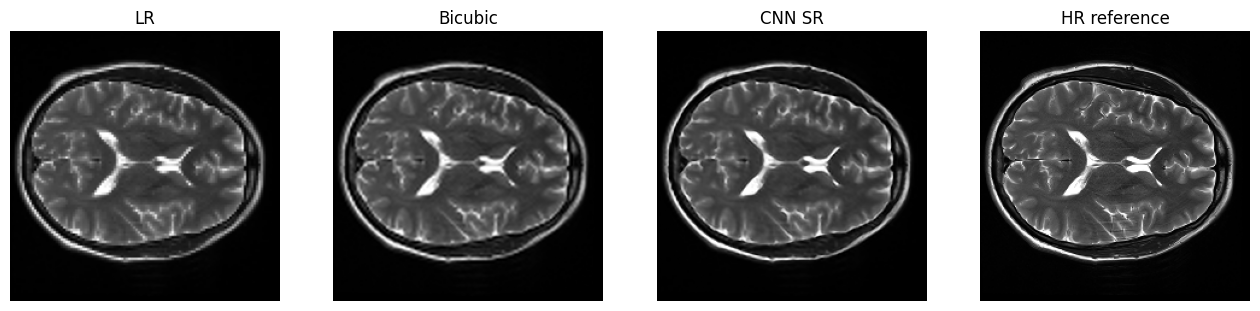

In [ ]:
fig, ax = plt.subplots(
    1, 4,
    figsize=(16, 4)
)

ax[0].imshow(
    lr,
    cmap="gray",
)
ax[0].set_title("LR")

ax[1].imshow(
    bicubic,
    cmap="gray",
)
ax[1].set_title("Bicubic")

ax[2].imshow(
    sr_prediction,
    cmap="gray",
    vmin=0,
    vmax=1

)
ax[2].set_title("CNN SR")

ax[3].imshow(
    hr,
    cmap="gray"
)
ax[3].set_title("HR reference")

for a in ax:
    a.axis("off")

plt.show()

In [ ]:
print("Bicubic")
print(
    "PSNR:",
    psnr(hr, bicubic)
)
print(
    "SSIM:",
    ssim(
        hr,
        bicubic,
        data_range=1.0
    )
)

print("\nCNN SR")
print(
    "PSNR:",
    psnr(hr, sr_prediction)
)
print(
    "SSIM:",
    ssim(
        hr,
        sr_prediction,
        data_range=1.0
    )
)

Bicubic
PSNR: 25.799744
SSIM: 0.9104110473414002

CNN SR
PSNR: 27.386082
SSIM: 0.9202344864881704


# Test on another slice using LF input

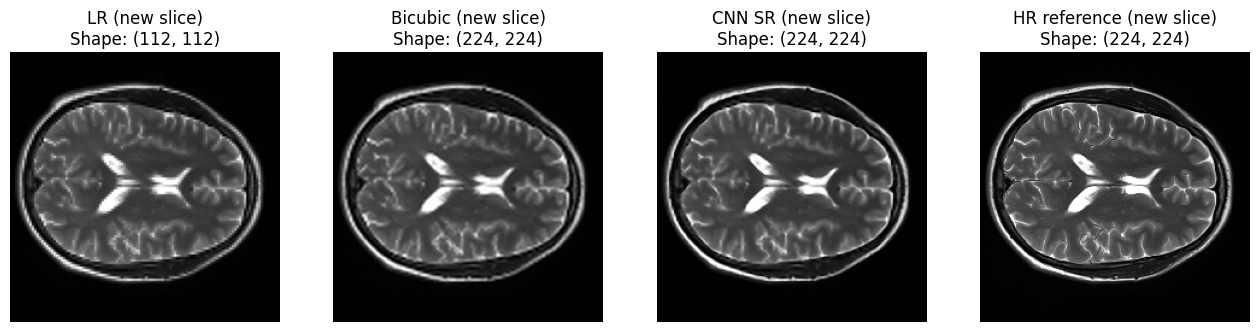


--- Evaluation for new slice ---
Bicubic
PSNR: 26.454556
SSIM: 0.921919371975231

CNN SR
PSNR: 27.763357
SSIM: 0.9278603505618574

Min/Max of each image for new slice:
-------------------------------------
LR           | Min: 0.0000, Max: 1.0000
Bicubic      | Min: 0.0000, Max: 1.0000
CNN SR       | Min: 0.0000, Max: 1.0000
HR reference | Min: 0.0000, Max: 1.0000


In [ ]:
new_slice_idx = 85 # Choose a different slice index

# 1. Select the new HR slice and normalize it
hr_new_original = volume[:, :, new_slice_idx].astype(np.float32)
hr_new = normalize_image(hr_new_original);

# 2. Create the corresponding LR image
lr_new = resize(
    hr_new,
    (
        hr_new.shape[0] // scale,
        hr_new.shape[1] // scale
    ),
    order=3,
    preserve_range=True,
    anti_aliasing=True
).astype(np.float32);

# 3. Create interpolated versions of the LR image
bicubic_new = resize(
    lr_new,
    hr_new.shape,
    order=3,
    preserve_range=True,
    anti_aliasing=False
);

# 4. Get SR prediction from the trained CNN model
model.eval()
lr_new_tensor = torch.from_numpy(
    lr_new
).float().unsqueeze(0).unsqueeze(0);
lr_new_tensor = lr_new_tensor.to(device);

with torch.no_grad():
    sr_prediction_new = model(
        lr_new_tensor
    );

sr_prediction_new = (
    sr_prediction_new
    .squeeze()
    .cpu()
    .numpy()
);
sr_prediction_new = np.clip(
    sr_prediction_new,
    0,
    1
);

# 5. Display the results
fig, ax = plt.subplots(
    1, 4,
    figsize=(16, 4)
)

ax[0].imshow(
    lr_new,
    cmap="gray",
)
ax[0].set_title(f"LR (new slice)\nShape: {lr_new.shape}")

ax[1].imshow(
    bicubic_new,
    cmap="gray",
)
ax[1].set_title(f"Bicubic (new slice)\nShape: {bicubic_new.shape}")

ax[2].imshow(
    sr_prediction_new,
    cmap="gray",
    vmin=0,
    vmax=1
)
ax[2].set_title(f"CNN SR (new slice)\nShape: {sr_prediction_new.shape}")

ax[3].imshow(
    hr_new,
    cmap="gray"
)
ax[3].set_title(f"HR reference (new slice)\nShape: {hr_new.shape}")

for a in ax:
    a.axis("off")

plt.show()

# 6. Print evaluation metrics
print("\n--- Evaluation for new slice ---")
print("Bicubic")
print(
    "PSNR:",
    psnr(hr_new, bicubic_new)
)
print(
    "SSIM:",
    ssim(
        hr_new,
        bicubic_new,
        data_range=1.0
    )
)

print("\nCNN SR")
print(
    "PSNR:",
    psnr(hr_new, sr_prediction_new)
)
print(
    "SSIM:",
    ssim(
        hr_new,
        sr_prediction_new,
        data_range=1.0
    )
)

# 7. Print min/max values
print("\nMin/Max of each image for new slice:")
print("-------------------------------------")

for name, image in [
    ("LR", lr_new),
    ("Bicubic", bicubic_new),
    ("CNN SR", sr_prediction_new),
    ("HR reference", hr_new)
]:
    print(f"{name:12s} | Min: {image.min():.4f}, Max: {image.max():.4f}")

# Module 19 — Understanding Supervised SR

We trained the network using:

    LR₁ ↔ HR₁
    LR₂ ↔ HR₂
    LR₃ ↔ HR₃
    ...
    LRₙ ↔ HRₙ

The network learned:

    fθ(LR) → HR-like reconstruction

The HR image was explicitly available during training.

This is called:

# Supervised Super-Resolution

# Module 22 — What If HR Does Not Exist?

Everything we did depended on:

    LR + HR

The training process was:

                HR target
                    ↑
                    │
    LR → CNN → SR → Loss
                    │
                    ↓
                Optimizer

But suppose we have only:

                ONE LR MRI

and no corresponding clean HR MRI.

Then:

                LR → CNN → SR
                              ↑
                              ?
                         No HR target

How can we train?

This is the problem that motivates
**Zero-Shot Super-Resolution (ZSSR)**.

# Module 23 — Preview of Zero-Shot SR


> Can the image itself provide the training information?

The basic idea behind ZSSR is to generate
**internal training examples from the image itself**.

Conceptually:

                Image
                  │
             degradation
                  ↓
            smaller image
                  │
                  ↓
          internal training


---

# Module 24 — Final checkpoint


```markdown
# Final Checkpoint

Before moving to ZSSR, make sure you can answer:

### Conceptual

1. What is the difference between HR and LR?
2. What is image degradation?
3. Why is interpolation not the same as SR?
4. What does a CNN learn in supervised SR?
5. Why are LR-HR patches required to be aligned?

### CNN

6. What does a convolution layer do?
7. Why do we use nonlinear activation functions?
8. What does the loss function measure?
9. What does backpropagation do?
10. What does the optimizer update?

### SR

11. What is the difference between upsampling and super-resolution?
12. Why can patch extraction be useful?
13. Why can supervised SR fail to generalize?
14. Why is hallucination a concern in medical imaging?

### Most important question

15. What happens if we have an LR image but no HR target?

If you can answer Question 15, you are ready for:

# Notebook 1.2 — Zero-Shot Super-Resolution